# Liu (2025) Cross-Sectional Recreation — v2

Clean rebuild using only `liu_exact_replication.csv`.

**Figures:**
- Fig 2C–H — Per-subject ROI peak scatter (native space)
- Fig 2I/J  — Crawford's modified *t* per patient (spatial)
- Fig 3A/B  — Example RDMs (lSTG/lVWFA control vs rSTG/rVWFA TC)
- Fig 3D    — Per-ROI Fisher-z boxplots
- Fig 3E    — Per-ROI Crawford's *t*

**Liu overlap:** sub-004 (UD), sub-021 (TC), sub-007 (OT, nonOTC control)

## 1. Setup

In [2]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import t as tdist

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

BASE    = Path(processed_dir)
LIU_CSV = Path('/user_data/csimmon2/git_repos/sym_pt/liu_exact_replication.csv')
FIG_DIR = Path('/user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact')
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE     = ['sub-017', 'sub-027']
EXCLUDE_SES = [('sub-108', 2)]

LIU_CODES = {'sub-004': 'UD', 'sub-021': 'TC', 'sub-007': 'OT'}

plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

print(f'LIU_CSV : {LIU_CSV}')
print(f'FIG_DIR : {FIG_DIR}')

LIU_CSV : /user_data/csimmon2/git_repos/sym_pt/liu_exact_replication.csv
FIG_DIR : /user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact


## 2. Load Liu-exact data

Cross-sectional: first session for controls, last session for patients.

- `le`: full long-format (one row per subject × session × roi × pair, 6 pairs per roi)
- `le_summary`: one row per subject × session × roi (distinctiveness + peak coords)
- `ctrl_le` / `pt_le`: session-selected summary
- `ctrl_pw` / `pt_pw`: session-selected pairwise (for RDMs)

In [3]:
le = pd.read_csv(LIU_CSV)
le = le[~le['subject_id'].isin(EXCLUDE)]
le['ses_num'] = pd.to_numeric(le['session'], errors='coerce').astype(int)
for bad_sub, bad_ses in EXCLUDE_SES:
    le = le[~((le['subject_id'] == bad_sub) & (le['ses_num'] == bad_ses))]

le_summary = le.drop(columns=['pair', 'fisher_r']).drop_duplicates().copy()

# Controls → first session
ctrl_all = le_summary[le_summary['status'] == 'control']
fs = ctrl_all.groupby('subject_id')['ses_num'].min().reset_index().rename(columns={'ses_num': 'keep'})
ctrl_le = ctrl_all.merge(fs, on='subject_id')
ctrl_le = ctrl_le[ctrl_le['ses_num'] == ctrl_le['keep']].drop(columns='keep')

# OTC patients → last session
pt_all = le_summary[le_summary['group'] == 'OTC']
ls = pt_all.groupby('subject_id')['ses_num'].max().reset_index().rename(columns={'ses_num': 'keep'})
pt_le = pt_all.merge(ls, on='subject_id')
pt_le = pt_le[pt_le['ses_num'] == pt_le['keep']].drop(columns='keep')

# Pairwise (same session selection)
ctrl_pw = le[le['status'] == 'control'].merge(fs, on='subject_id')
ctrl_pw = ctrl_pw[ctrl_pw['ses_num'] == ctrl_pw['keep']].drop(columns='keep')
pt_pw = le[le['group'] == 'OTC'].merge(ls, on='subject_id')
pt_pw = pt_pw[pt_pw['ses_num'] == pt_pw['keep']].drop(columns='keep')

ctrl_subs = sorted(ctrl_le['subject_id'].unique())
otc_subs  = sorted(pt_le['subject_id'].unique())

print(f'Controls: {len(ctrl_subs)}')
print(f'OTC patients: {len(otc_subs)}')
print(f'  Overlap with Liu: {[s for s in otc_subs if s in LIU_CODES]}')

Controls: 21
OTC patients: 16
  Overlap with Liu: ['sub-004', 'sub-021']


## 3. Shared helpers

In [4]:
def crawford(x, c):
    """Crawford & Howell (1998) modified t, returns (t, p)."""
    c = np.asarray(c); c = c[~np.isnan(c)]
    if len(c) < 3 or np.isnan(x): return np.nan, np.nan
    m, sd = c.mean(), c.std(ddof=1)
    if sd == 0: return np.nan, np.nan
    t = (x - m) / (sd * np.sqrt((len(c) + 1) / len(c)))
    p = 2 * (1 - tdist.cdf(abs(t), df=len(c) - 1))
    return t, p

def fisher_z(r):
    r = np.clip(np.asarray(r, float), -0.9999, 0.9999)
    return 0.5 * np.log((1 + r) / (1 - r))

WORD_CATS = {'word_VWFA', 'word_STG'}

def pt_intact_hemi(sub):
    """Return 'l' or 'r' for a patient's intact hemisphere."""
    sd = pt_le[pt_le['subject_id'] == sub]
    if sd.empty: return None
    intact = sd['intact_hemi'].iloc[0]
    return 'l' if intact == 'left' else 'r' if intact == 'right' else None

## 4. Fig 2C–H — Per-subject ROI peak scatter

Native space coordinates. LH = negative x, RH = positive x; natural axis orientation.

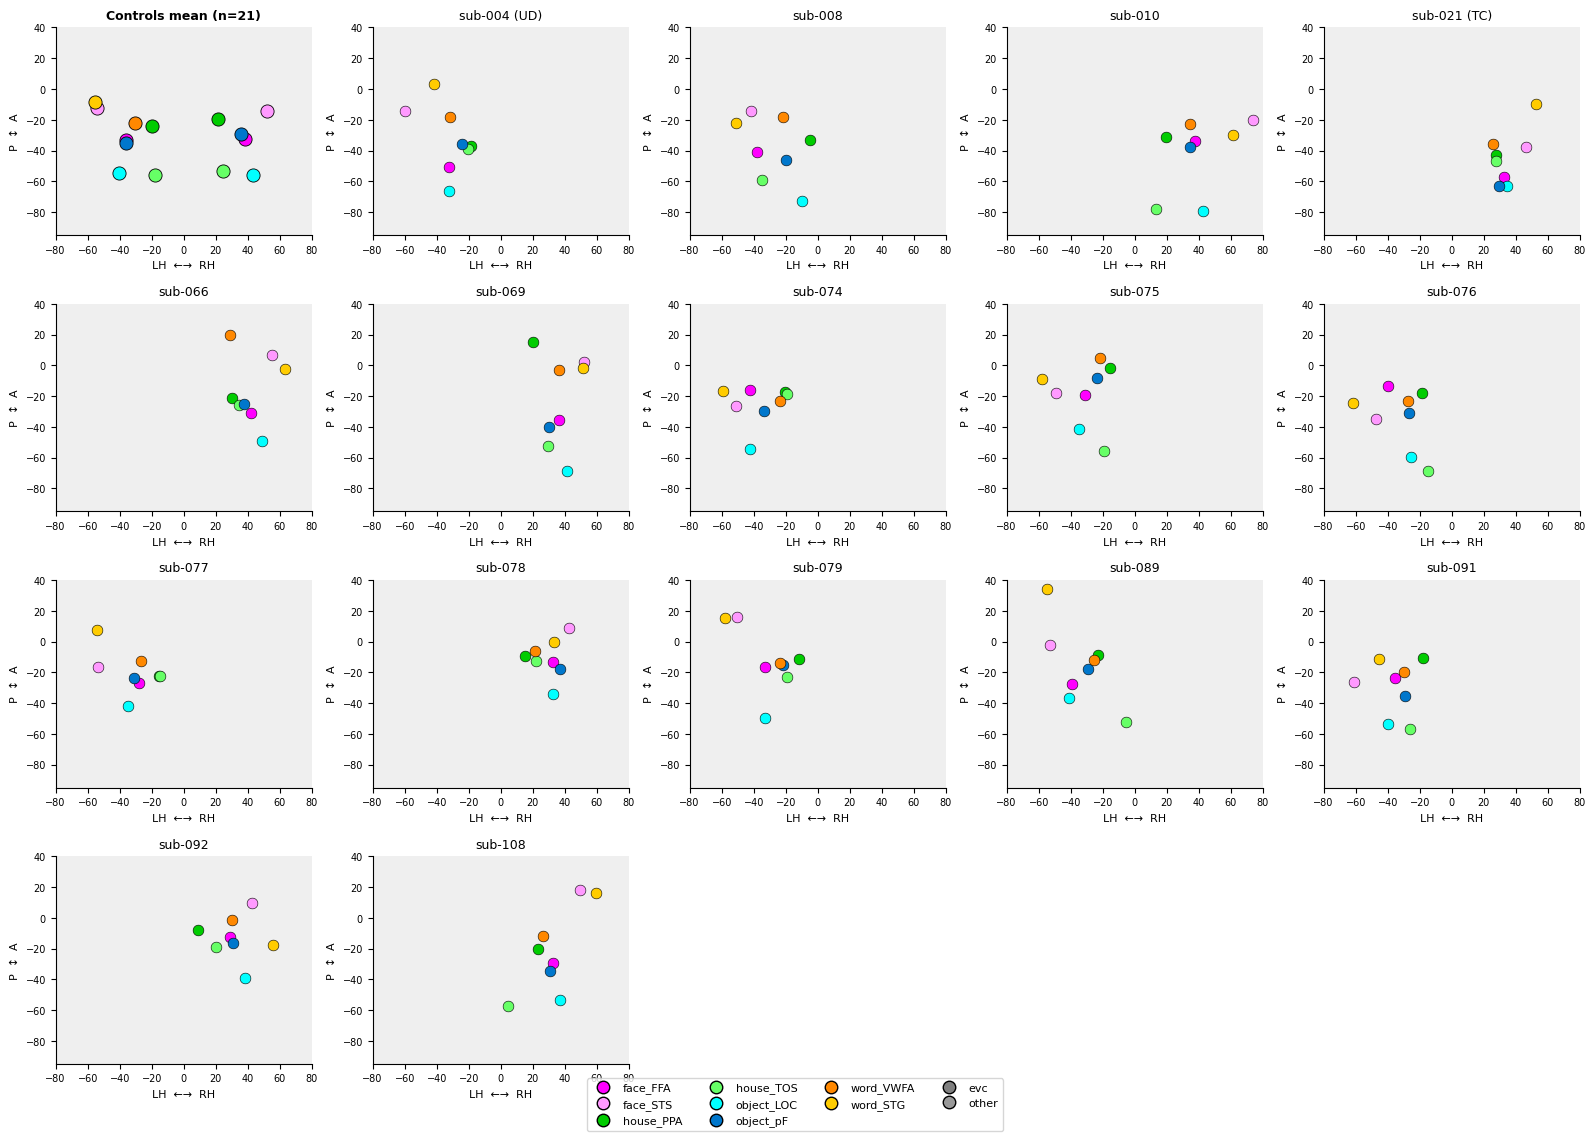

In [5]:
ROI_COLOR = {
    'face_FFA':   'magenta',  'face_STS':    '#ff99ff',
    'house_PPA':  '#00cc00',  'house_TOS':   '#66ff66',
    'object_LOC': 'cyan',     'object_pF':   '#0077cc',
    'word_VWFA':  '#ff8800',  'word_STG':    '#ffcc00',
    'evc':        'gray',     'other':       '#999999',
}
ALL_CATS = list(ROI_COLOR.keys())

XLIM = (-80, 80)
YLIM = (-95, 40)

def scatter_subject(ax, df, sub, title):
    for cat in ALL_CATS:
        for h in ('l', 'r'):
            m = df[(df['subject_id'] == sub) & (df['category'] == cat) & (df['hemi'] == h)]
            if not len(m): continue
            ax.scatter(m['peak_x_mni'].iloc[0], m['peak_y_mni'].iloc[0],
                       s=60, c=ROI_COLOR[cat], edgecolors='k', linewidth=0.4)
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
    ax.set_xlabel('LH  ←→  RH', fontsize=8)
    ax.set_ylabel('P  ↕  A', fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.set_facecolor('#efefef')
    ax.tick_params(labelsize=7)

n_pt = len(otc_subs)
n_cols = 5
n_rows = int(np.ceil((n_pt + 1) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 2.8 * n_rows))
axes = axes.flatten()

# Controls mean
ax = axes[0]
for cat in ALL_CATS:
    for h in ('l', 'r'):
        xs, ys = [], []
        for s in ctrl_subs:
            m = ctrl_le[(ctrl_le['subject_id'] == s) & (ctrl_le['category'] == cat) & (ctrl_le['hemi'] == h)]
            if len(m):
                xs.append(m['peak_x_mni'].iloc[0]); ys.append(m['peak_y_mni'].iloc[0])
        if xs:
            ax.scatter(np.mean(xs), np.mean(ys), s=90, c=ROI_COLOR[cat], edgecolors='k', linewidth=0.6)
ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
ax.set_title(f'Controls mean (n={len(ctrl_subs)})', fontsize=9, fontweight='bold')
ax.set_xlabel('LH  ←→  RH', fontsize=8); ax.set_ylabel('P  ↕  A', fontsize=8)
ax.set_facecolor('#efefef'); ax.tick_params(labelsize=7)

for i, s in enumerate(otc_subs):
    code_s = LIU_CODES.get(s, '')
    label = f'{s} ({code_s})' if code_s else s
    scatter_subject(axes[i + 1], pt_le, s, label)

for j in range(n_pt + 1, len(axes)):
    axes[j].axis('off')

legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                             markeredgecolor='k', markersize=9, label=cat)
                  for cat, c in ROI_COLOR.items()]
fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_exact_fig2CH.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Fig 2I/J — Spatial correlation Crawford *t*

Correlate each patient's ventral x-coordinate vector (medial-lateral organization) with the control mean. Crawford *t* tests whether patient's Fisher-z falls outside the control leave-one-out null distribution.

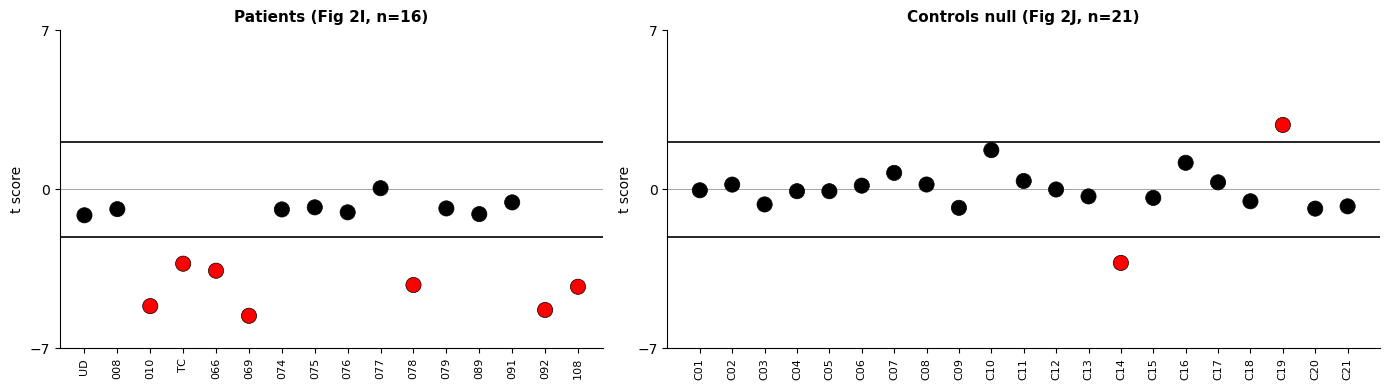

In [6]:
VENTRAL_KEY = [('face_FFA',  'l'), ('face_FFA',  'r'),
               ('house_PPA', 'l'), ('house_PPA', 'r'),
               ('object_pF', 'l'), ('object_pF', 'r'),
               ('word_VWFA', 'PREF')]

def resolve_hemi(hspec, is_ctrl, intact):
    if hspec in ('l', 'r'): return hspec
    if hspec == 'PREF':
        if is_ctrl: return 'l'
        return 'l' if intact == 'left' else 'r' if intact == 'right' else None
    return None

def build_xmat(df, subs, is_ctrl, intact_map):
    X = np.full((len(VENTRAL_KEY), len(subs)), np.nan)
    for i, (cat, hspec) in enumerate(VENTRAL_KEY):
        for j, s in enumerate(subs):
            h = resolve_hemi(hspec, is_ctrl, intact_map.get(s))
            if h is None: continue
            m = df[(df['subject_id'] == s) & (df['category'] == cat) & (df['hemi'] == h)]
            if len(m): X[i, j] = m['peak_x_mni'].iloc[0]
    return X

intact_map = dict(zip(le_summary['subject_id'], le_summary['intact_hemi']))
X_ctrl = build_xmat(ctrl_le, ctrl_subs, True, intact_map)
X_pt   = build_xmat(pt_le,   otc_subs,  False, intact_map)
n_ctrl = len(ctrl_subs)

# Patient spatial correlations vs control mean
spcor_pt   = np.full(len(otc_subs), np.nan)
null_forpt = np.full((n_ctrl, len(otc_subs)), np.nan)
for p, s in enumerate(otc_subs):
    valid = ~np.isnan(X_pt[:, p])
    if valid.sum() < 3: continue
    pat_vec = X_pt[valid, p]
    ctrl_sub = X_ctrl[valid, :]
    mean_ctrl = np.nanmean(ctrl_sub, axis=1)
    ok = ~np.isnan(pat_vec) & ~np.isnan(mean_ctrl)
    if ok.sum() >= 3:
        spcor_pt[p] = np.corrcoef(pat_vec[ok], mean_ctrl[ok])[0, 1]
    for t_idx in range(n_ctrl):
        others = [c for c in range(n_ctrl) if c != t_idx]
        rest = np.nanmean(ctrl_sub[:, others], axis=1)
        me = ctrl_sub[:, t_idx]
        ok = ~np.isnan(me) & ~np.isnan(rest)
        if ok.sum() >= 3:
            null_forpt[t_idx, p] = np.corrcoef(me[ok], rest[ok])[0, 1]

# Control leave-one-out null
spcor_ctrl = np.full(n_ctrl, np.nan)
for c in range(n_ctrl):
    others = [j for j in range(n_ctrl) if j != c]
    rest = np.nanmean(X_ctrl[:, others], axis=1)
    me = X_ctrl[:, c]
    ok = ~np.isnan(me) & ~np.isnan(rest)
    if ok.sum() >= 6:
        spcor_ctrl[c] = np.corrcoef(me[ok], rest[ok])[0, 1]

spcor_pt_fz   = fisher_z(spcor_pt)
null_pt_fz    = fisher_z(null_forpt)
spcor_ctrl_fz = fisher_z(spcor_ctrl)

t_pt = np.array([crawford(spcor_pt_fz[p], null_pt_fz[:, p])[0] for p in range(len(otc_subs))])
t_ctrl = np.array([crawford(spcor_ctrl_fz[c], np.delete(spcor_ctrl_fz, c))[0] for c in range(n_ctrl)])
crit_2I = float(tdist.ppf(0.975, df=n_ctrl - 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4),
                         gridspec_kw={'width_ratios': [len(otc_subs), n_ctrl]})
for ax, tvals, labels, title in [
    (axes[0], t_pt, [LIU_CODES.get(s, s.replace('sub-', '')) for s in otc_subs],
     f'Patients (Fig 2I, n={len(otc_subs)})'),
    (axes[1], t_ctrl, [f'C{i+1:02d}' for i in range(n_ctrl)],
     f'Controls null (Fig 2J, n={n_ctrl})')]:
    xs = np.arange(len(tvals))
    colors = ['red' if (not np.isnan(v) and abs(v) > crit_2I) else 'black' for v in tvals]
    ax.scatter(xs, tvals, s=120, c=colors, edgecolors='k', linewidth=0.5, zorder=3)
    ax.axhline( crit_2I, color='k', lw=1.2)
    ax.axhline(-crit_2I, color='k', lw=1.2)
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_ylim(-7, 7); ax.set_yticks([-7, 0, 7])
    ax.set_xticks(xs); ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_ylabel('t score')
    ax.set_title(title, fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_exact_fig2IJ.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Fig 3A/B — Example RDMs

Pearson *r* (Liu Fig 3 convention), vmin=0 vmax=1 (negatives render as black, matching Liu).
Control exemplar = median word-vs-other correlation (typical, not extreme).

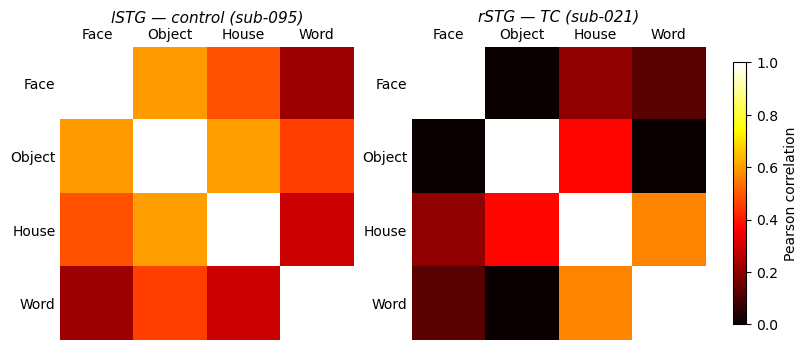

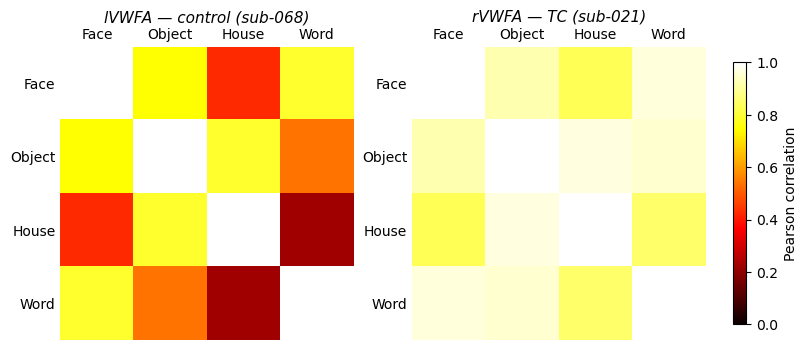

In [7]:
CATS4 = ['face', 'object', 'house', 'word']

def rdm(subj_pw):
    M = np.full((4, 4), np.nan)
    for i, a in enumerate(CATS4):
        for j, b in enumerate(CATS4):
            if i == j:
                M[i, j] = 1.0
                continue
            hit = subj_pw[subj_pw['pair'].isin([f'{a}-{b}', f'{b}-{a}'])]
            if len(hit):
                M[i, j] = np.tanh(hit['fisher_r'].iloc[0])   # Pearson r
    return M

def plot_rdm_pair(roi, ctrl_sub, pt_sub, pt_hemi, fname):
    ctrl_q = ctrl_pw[(ctrl_pw['subject_id'] == ctrl_sub) &
                     (ctrl_pw['category'] == roi) & (ctrl_pw['hemi'] == 'l')]
    pt_q = pt_pw[(pt_pw['subject_id'] == pt_sub) &
                 (pt_pw['category'] == roi) & (pt_pw['hemi'] == pt_hemi)]
    if not len(ctrl_q) or not len(pt_q):
        print(f'  skip {roi}: ctrl rows={len(ctrl_q)}, pt rows={len(pt_q)}')
        return
    ctrl_rdm, pt_rdm = rdm(ctrl_q), rdm(pt_q)
    short = roi.split('_')[-1]
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    for ax, M, ttl in [(axes[0], ctrl_rdm, f'l{short} — control ({ctrl_sub})'),
                       (axes[1], pt_rdm,   f'{pt_hemi}{short} — TC ({pt_sub})')]:
        im = ax.imshow(M, cmap='hot', vmin=0, vmax=1, aspect='equal')
        ax.set_xticks(range(4)); ax.set_yticks(range(4))
        ax.set_xticklabels(['Face', 'Object', 'House', 'Word'], fontsize=10)
        ax.set_yticklabels(['Face', 'Object', 'House', 'Word'], fontsize=10)
        ax.xaxis.tick_top()
        ax.set_title(ttl, fontsize=11, style='italic', pad=18)
        ax.tick_params(length=0)
        for s in ax.spines.values(): s.set_visible(False)
    fig.colorbar(im, ax=axes, fraction=0.035, pad=0.04, shrink=0.85,
                 label='Pearson correlation')
    plt.savefig(FIG_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

for roi, fname in [('word_STG',  'liu_exact_fig3AB_STG.png'),
                   ('word_VWFA', 'liu_exact_fig3AB_VWFA.png')]:
    cset = ctrl_pw[(ctrl_pw['category'] == roi) & (ctrl_pw['hemi'] == 'l')]
    piv = cset.pivot_table(index='subject_id', columns='pair', values='fisher_r')
    pairs_needed = [p for p in ['face-word', 'object-word', 'house-word'] if p in piv.columns]
    if pairs_needed:
        piv['score'] = piv[pairs_needed].mean(axis=1)
        ctrl_ex = (piv['score'] - piv['score'].median()).abs().idxmin()
    else:
        ctrl_ex = sorted(cset['subject_id'].unique())[0]
    plot_rdm_pair(roi, ctrl_ex, 'sub-021', 'r', fname)

## 7. Fig 3D — Per-ROI Fisher-z boxplots

Control distributions as boxes; patient markers at their intact hemisphere. Word ROIs (VWFA/STG) have a single slot — LH for controls, intact hemi for patients ("folded").

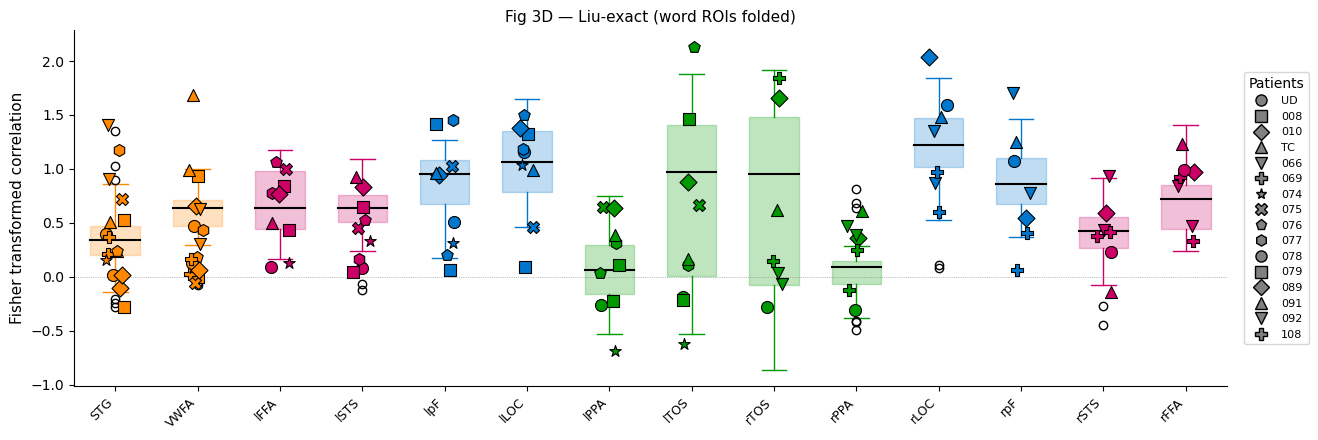

In [8]:
ROI_ORDER = [
    ('word_STG',   'PREF'), ('word_VWFA',  'PREF'),
    ('face_FFA',   'l'),    ('face_STS',   'l'),
    ('object_pF',  'l'),    ('object_LOC', 'l'),
    ('house_PPA',  'l'),    ('house_TOS',  'l'),
    ('house_TOS',  'r'),    ('house_PPA',  'r'),
    ('object_LOC', 'r'),    ('object_pF',  'r'),
    ('face_STS',   'r'),    ('face_FFA',   'r'),
]

def roi_label(roi, hspec):
    s = roi.split('_')[-1]
    if hspec == 'PREF': return s
    return f'{"l" if hspec == "l" else "r"}{s}'

ROI_CAT_COLOR = {
    'word_STG':   '#ff8800', 'word_VWFA':  '#ff8800',
    'face_FFA':   '#cc0066', 'face_STS':   '#cc0066',
    'object_pF':  '#0077cc', 'object_LOC': '#0077cc',
    'house_PPA':  '#009900', 'house_TOS':  '#009900',
}

_mc = ['o', 's', 'D', '^', 'v', 'P', '*', 'X', 'p', 'h']
PT_MARKERS = {s: _mc[i % len(_mc)] for i, s in enumerate(otc_subs)}

n = len(ROI_ORDER)
fig, ax = plt.subplots(figsize=(max(14, n * 0.9), 4.5))
rng = np.random.RandomState(42)
JITTER = 0.12

for xi, (roi, hspec) in enumerate(ROI_ORDER):
    color = ROI_CAT_COLOR[roi]
    ctrl_h = 'l' if hspec == 'PREF' else hspec
    cvals = ctrl_le[(ctrl_le['category'] == roi) & (ctrl_le['hemi'] == ctrl_h)]['liu_distinctiveness'].dropna().values
    if len(cvals) == 0: continue

    ax.boxplot(cvals, positions=[xi], widths=0.6, patch_artist=True,
               medianprops={'color': 'black', 'lw': 1.5},
               whiskerprops={'color': color}, capprops={'color': color},
               boxprops={'facecolor': color, 'alpha': 0.25, 'edgecolor': color})

    for sub in otc_subs:
        pt_h = pt_intact_hemi(sub)
        if pt_h is None: continue
        if hspec == 'PREF':
            val = pt_le[(pt_le['subject_id'] == sub) & (pt_le['category'] == roi) &
                        (pt_le['hemi'] == pt_h)]['liu_distinctiveness'].values
        else:
            if pt_h != hspec: continue
            val = pt_le[(pt_le['subject_id'] == sub) & (pt_le['category'] == roi) &
                        (pt_le['hemi'] == hspec)]['liu_distinctiveness'].values
        if len(val) == 0 or np.isnan(val[0]): continue
        ax.scatter(xi + rng.uniform(-JITTER, JITTER), val[0],
                   marker=PT_MARKERS[sub], s=75, zorder=5,
                   edgecolors='black', linewidth=0.8, facecolors=color)

ax.set_xticks(np.arange(n))
ax.set_xticklabels([roi_label(c, h) for c, h in ROI_ORDER], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Fisher transformed correlation', fontsize=11)
ax.axhline(0, color='gray', lw=0.5, ls=':')
ax.set_title('Fig 3D — Liu-exact (word ROIs folded)', fontsize=11)

handles = [plt.Line2D([0], [0], marker=m, color='gray', linestyle='None', ms=8, mec='black',
                      label=LIU_CODES.get(s, s.replace('sub-', ''))) for s, m in PT_MARKERS.items()]
ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.01, 0.5),
          fontsize=8, title='Patients')
plt.tight_layout(); plt.subplots_adjust(right=0.88)
plt.savefig(FIG_DIR / 'liu_exact_fig3D.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Fig 3E — Per-ROI Crawford *t*

Patient distinctiveness vs control distribution, per ROI × per patient.

n_ctrl per ROI: min=20, max=21
Critical t (α=.05, 2-sided, min df=19): ±2.093



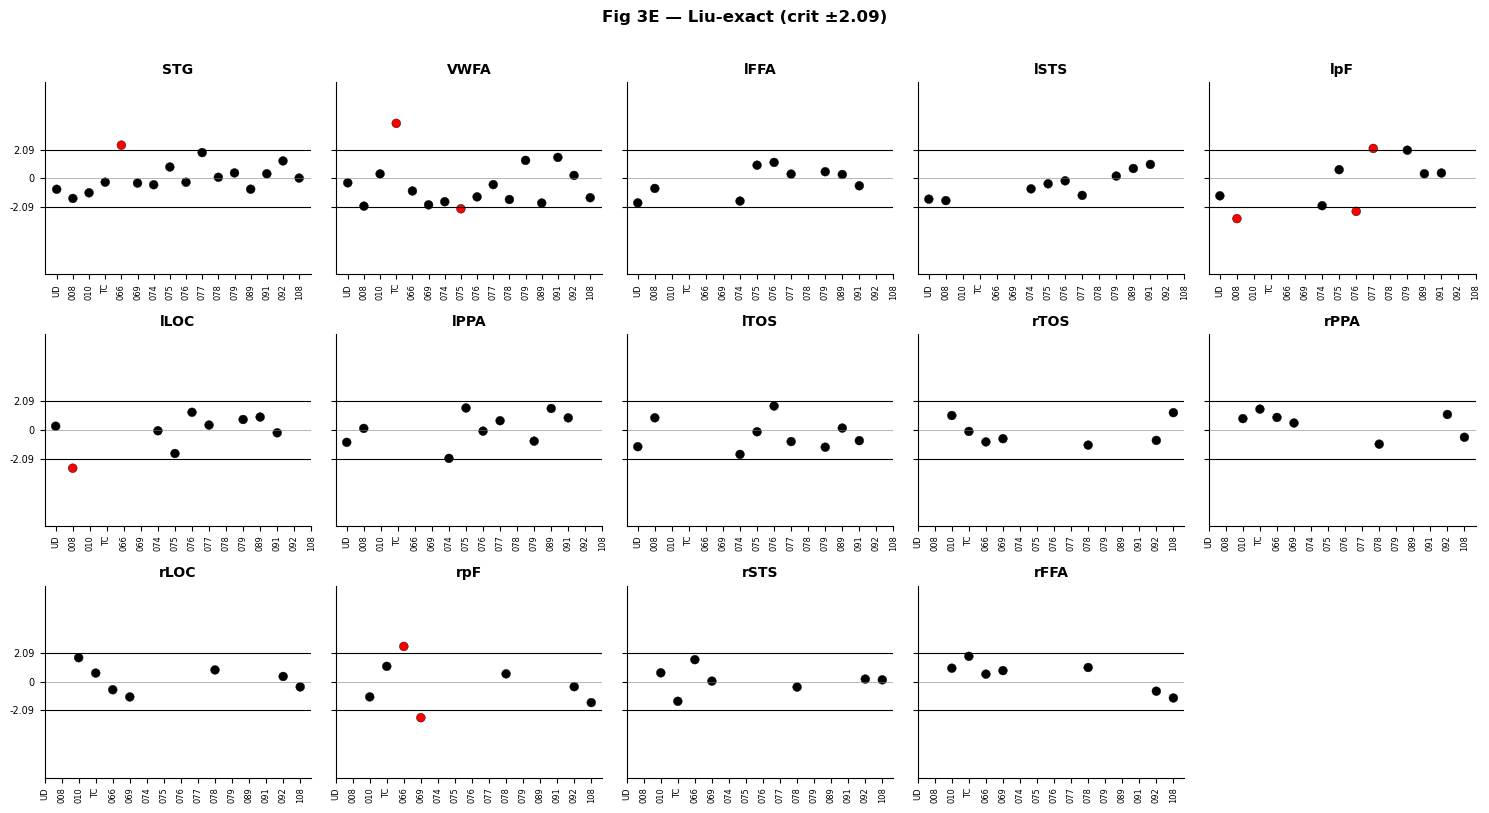

In [9]:
t_mat = np.full((n, len(otc_subs)), np.nan)
n_ctrls_roi = np.zeros(n, dtype=int)

for r, (roi, hspec) in enumerate(ROI_ORDER):
    ctrl_h = 'l' if hspec == 'PREF' else hspec
    cvals = ctrl_le[(ctrl_le['category'] == roi) & (ctrl_le['hemi'] == ctrl_h)]['liu_distinctiveness'].dropna().values
    n_ctrls_roi[r] = len(cvals)
    if len(cvals) < 3: continue

    for p_, sub in enumerate(otc_subs):
        pt_h = pt_intact_hemi(sub)
        if pt_h is None: continue
        if hspec == 'PREF':
            val = pt_le[(pt_le['subject_id'] == sub) & (pt_le['category'] == roi) &
                        (pt_le['hemi'] == pt_h)]['liu_distinctiveness'].values
        else:
            if pt_h != hspec: continue
            val = pt_le[(pt_le['subject_id'] == sub) & (pt_le['category'] == roi) &
                        (pt_le['hemi'] == hspec)]['liu_distinctiveness'].values
        if len(val) == 0 or np.isnan(val[0]): continue
        t_mat[r, p_], _ = crawford(val[0], cvals)

min_df = max(int(n_ctrls_roi[n_ctrls_roi > 0].min()) - 1, 1)
crit_3E = float(tdist.ppf(0.975, df=min_df))
print(f'n_ctrl per ROI: min={n_ctrls_roi[n_ctrls_roi>0].min()}, max={n_ctrls_roi.max()}')
print(f'Critical t (α=.05, 2-sided, min df={min_df}): ±{crit_3E:.3f}\n')

fig, axes = plt.subplots(3, 5, figsize=(15, 8), sharey=True)
axes = axes.flatten()
pt_labels = [LIU_CODES.get(s, s.replace('sub-', '')) for s in otc_subs]
for r, (roi, hspec) in enumerate(ROI_ORDER):
    ax = axes[r]
    xs = np.arange(len(otc_subs))
    tv = t_mat[r]
    colors = ['red' if (not np.isnan(v) and abs(v) > crit_3E) else 'black' for v in tv]
    ax.scatter(xs, tv, s=40, c=colors, edgecolors='k', linewidth=0.3)
    ax.axhline( crit_3E, color='k', lw=0.8)
    ax.axhline(-crit_3E, color='k', lw=0.8)
    ax.axhline(0, color='gray', lw=0.4)
    ax.set_ylim(-7, 7); ax.set_yticks([-crit_3E, 0, crit_3E])
    ax.set_yticklabels([f'{-crit_3E:.2f}', '0', f'{crit_3E:.2f}'], fontsize=7)
    ax.set_xticks(xs); ax.set_xticklabels(pt_labels, rotation=90, fontsize=6)
    ax.set_title(roi_label(roi, hspec), fontsize=10, fontweight='bold')
for r in range(n, len(axes)):
    axes[r].axis('off')
plt.suptitle(f'Fig 3E — Liu-exact (crit ±{crit_3E:.2f})', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_exact_fig3E.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Validation summary

TC (sub-021) remapped word ROIs vs control LH distribution.

In [10]:
print(f'TC (sub-021) remapped word ROIs vs control LH:')
for roi in ['word_VWFA', 'word_STG']:
    tc_val = pt_le[(pt_le['subject_id'] == 'sub-021') & (pt_le['category'] == roi) &
                   (pt_le['hemi'] == 'r')]['liu_distinctiveness'].values
    cvals = ctrl_le[(ctrl_le['category'] == roi) & (ctrl_le['hemi'] == 'l')]['liu_distinctiveness'].dropna().values
    if len(tc_val) and len(cvals):
        t, p = crawford(tc_val[0], cvals)
        sig = '*' if abs(t) > crit_3E else ''
        print(f'  r{roi.split("_")[-1]}: TC={tc_val[0]:.3f}, ctrl M={cvals.mean():.3f}, t={t:+.2f}, p={p:.3f} {sig}')

TC (sub-021) remapped word ROIs vs control LH:
  rVWFA: TC=1.688, ctrl M=0.566, t=+4.01, p=0.001 *
  rSTG: TC=0.238, ctrl M=0.362, t=-0.29, p=0.778 


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# Fig 2I/J overlay — x-coord Crawford t, all categories on same plot
# ═══════════════════════════════════════════════════════════════════════════════
CAT_ROI = [
    ('face',   'face_FFA'),
    ('house',  'house_PPA'),
    ('object', 'object_pF'),
    ('word',   'word_VWFA'),
]
CAT_COLOR = {'face':'#cc0066','house':'#009900','object':'#0077cc','word':'#ff8800'}

def pt_hemi_for(sub):
    return pt_intact_hemi(sub)

# For each category × patient: patient value at intact hemi vs control intact-hemi-matched distribution
# (for word: ctrl uses LH; for other cats: ctrl uses hemi matching patient's intact)
t_cat_pt   = {cat: np.full(len(otc_subs), np.nan) for cat, _ in CAT_ROI}
t_cat_ctrl = {cat: np.full(n_ctrl, np.nan) for cat, _ in CAT_ROI}

for cat, roi in CAT_ROI:
    for p, sub in enumerate(otc_subs):
        pt_h = pt_hemi_for(sub)
        if pt_h is None: continue
        ctrl_h = 'l' if cat == 'word' else pt_h
        cvals = np.array([get_x(ctrl_le, s, roi, ctrl_h) for s in ctrl_subs])
        cvals_valid = cvals[~np.isnan(cvals)]
        if len(cvals_valid) < 3: continue
        x = get_x(pt_le, sub, roi, pt_h)
        if np.isnan(x): continue
        t_cat_pt[cat][p], _ = crawford(x, cvals_valid)

    # Control null: each control vs rest, using LH (or both for bilateral)
    ctrl_h = 'l' if cat == 'word' else 'l'   # use LH for overlay simplicity
    cvals = np.array([get_x(ctrl_le, s, roi, ctrl_h) for s in ctrl_subs])
    for c in range(n_ctrl):
        if np.isnan(cvals[c]): continue
        others = np.delete(cvals, c)
        others = others[~np.isnan(others)]
        if len(others) < 3: continue
        t_cat_ctrl[cat][c], _ = crawford(cvals[c], others)

min_df = max(n_ctrl - 1, 3)
crit = float(tdist.ppf(0.975, df=min_df))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5),
                         gridspec_kw={'width_ratios':[len(otc_subs), n_ctrl]})
pt_labels = [LIU_CODES.get(s, s.replace('sub-','')) for s in otc_subs]
ctrl_labels = [f'C{i+1:02d}' for i in range(n_ctrl)]

offsets = {'face':-0.3, 'house':-0.1, 'object':0.1, 'word':0.3}

# Patients
ax = axes[0]
for cat, _ in CAT_ROI:
    xs = np.arange(len(otc_subs)) + offsets[cat]
    tv = t_cat_pt[cat]
    for i, v in enumerate(tv):
        if np.isnan(v): continue
        sig = abs(v) > crit
        ax.scatter(xs[i], v, s=60,
                   c=CAT_COLOR[cat] if sig else 'white',
                   edgecolors=CAT_COLOR[cat], linewidth=1.2, zorder=3)
ax.axhline( crit, color='k', lw=1.0); ax.axhline(-crit, color='k', lw=1.0)
ax.axhline(0, color='gray', lw=0.5)
ax.set_ylim(-7, 7); ax.set_yticks([-7, 0, 7])
ax.set_xticks(np.arange(len(otc_subs))); ax.set_xticklabels(pt_labels, rotation=90, fontsize=8)
ax.set_ylabel('t score')
ax.set_title(f'Patients (Fig 2I, n={len(otc_subs)})', fontsize=11, fontweight='bold')

# Controls null
ax = axes[1]
for cat, _ in CAT_ROI:
    xs = np.arange(n_ctrl) + offsets[cat]
    tv = t_cat_ctrl[cat]
    for i, v in enumerate(tv):
        if np.isnan(v): continue
        sig = abs(v) > crit
        ax.scatter(xs[i], v, s=60,
                   c=CAT_COLOR[cat] if sig else 'white',
                   edgecolors=CAT_COLOR[cat], linewidth=1.2, zorder=3)
ax.axhline( crit, color='k', lw=1.0); ax.axhline(-crit, color='k', lw=1.0)
ax.axhline(0, color='gray', lw=0.5)
ax.set_ylim(-7, 7); ax.set_yticks([-7, 0, 7])
ax.set_xticks(np.arange(n_ctrl)); ax.set_xticklabels(ctrl_labels, rotation=90, fontsize=8)
ax.set_title(f'Controls null (Fig 2J, n={n_ctrl})', fontsize=11, fontweight='bold')

legend_handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=c,
                             markeredgecolor=c, markersize=9, label=cat)
                  for cat, c in CAT_COLOR.items()]
fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.02), title='Category (filled = significant)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_exact_fig2IJ_overlay.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'get_x' is not defined

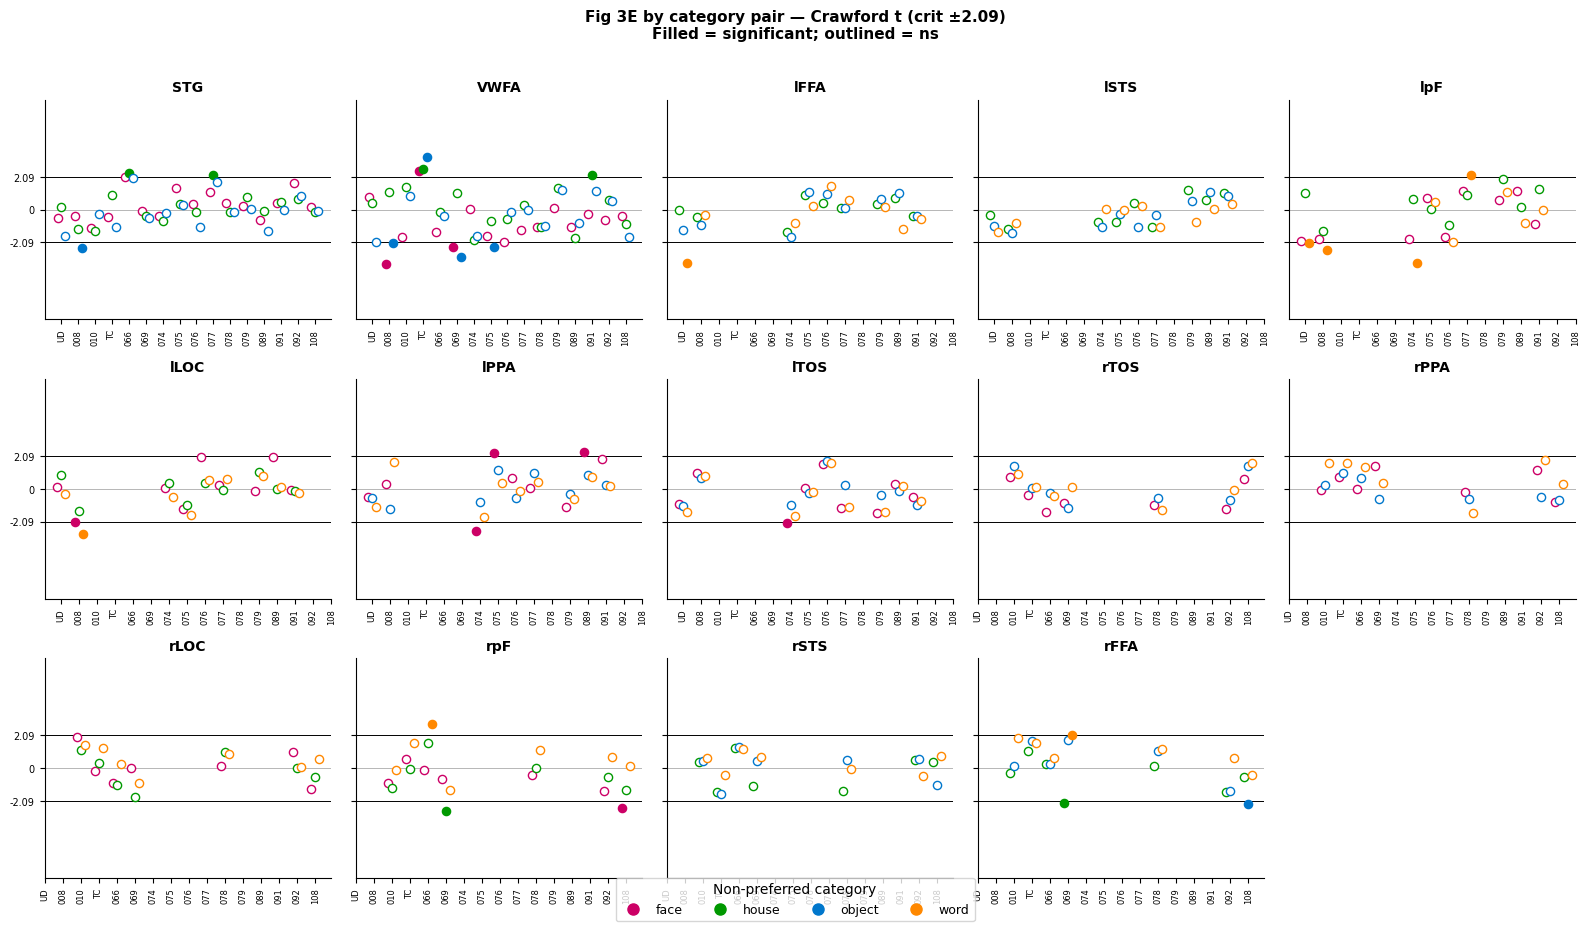

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Fig 3E by category pair — preferred-vs-each-non-preferred, not collapsed
# Per ROI × patient, 3 Crawford t's (one per non-preferred category)
# ═══════════════════════════════════════════════════════════════════════════════
PARENT = {'face_FFA':'face','face_STS':'face',
          'house_PPA':'house','house_TOS':'house',
          'object_pF':'object','object_LOC':'object',
          'word_VWFA':'word','word_STG':'word'}

CAT_COLOR = {'face':'#cc0066','house':'#009900','object':'#0077cc','word':'#ff8800'}

def get_pair_fz(df, sub, cat, hemi, pair_str):
    """Return Fisher-z for a given pair, handling both 'face-word' and 'word-face'."""
    a, b = pair_str.split('-')
    m = df[(df['subject_id']==sub) & (df['category']==cat) & (df['hemi']==hemi) &
           (df['pair'].isin([f'{a}-{b}', f'{b}-{a}']))]
    return m['fisher_r'].iloc[0] if len(m) else np.nan

# Build per-pair t matrix: (n_roi, n_patient, 3 non-preferred cats)
n_rois_3e = len(ROI_ORDER)
NONPREF_CATS = {}  # roi → list of 3 non-preferred base categories
for roi, _ in ROI_ORDER:
    pref = PARENT[roi]
    NONPREF_CATS[roi] = [c for c in ['face','house','object','word'] if c != pref]

t_pair_mat = np.full((n_rois_3e, len(otc_subs), 3), np.nan)
n_ctrl_per_pair = np.zeros((n_rois_3e, 3), dtype=int)

for r, (roi, hspec) in enumerate(ROI_ORDER):
    pref = PARENT[roi]
    ctrl_h = 'l' if hspec=='PREF' else hspec
    for k, nonpref in enumerate(NONPREF_CATS[roi]):
        pair_str = f'{pref}-{nonpref}'
        cvals = np.array([get_pair_fz(ctrl_pw, s, roi, ctrl_h, pair_str) for s in ctrl_subs])
        cvals = cvals[~np.isnan(cvals)]
        n_ctrl_per_pair[r, k] = len(cvals)
        if len(cvals) < 3: continue

        for p, sub in enumerate(otc_subs):
            pt_h = pt_intact_hemi(sub)
            if pt_h is None: continue
            if hspec == 'PREF':
                x = get_pair_fz(pt_pw, sub, roi, pt_h, pair_str)
            else:
                if pt_h != hspec: continue
                x = get_pair_fz(pt_pw, sub, roi, hspec, pair_str)
            if np.isnan(x): continue
            t_pair_mat[r, p, k], _ = crawford(x, cvals)

min_df_3e = max(int(n_ctrl_per_pair[n_ctrl_per_pair>0].min()) - 1, 1)
crit_3ep = float(tdist.ppf(0.975, df=min_df_3e))

# Plot: 3 rows × 5 cols, one subplot per ROI, 3 jittered dots per patient (color=non-pref cat)
fig, axes = plt.subplots(3, 5, figsize=(16, 9), sharey=True)
axes = axes.flatten()
pt_labels = [LIU_CODES.get(s, s.replace('sub-','')) for s in otc_subs]

for r, (roi, hspec) in enumerate(ROI_ORDER):
    ax = axes[r]
    xs_base = np.arange(len(otc_subs))
    offsets = [-0.22, 0, 0.22]

    for k, nonpref in enumerate(NONPREF_CATS[roi]):
        xs = xs_base + offsets[k]
        tv = t_pair_mat[r, :, k]
        colors = [CAT_COLOR[nonpref] if (not np.isnan(v) and abs(v)>crit_3ep)
                  else '#cccccc' if np.isnan(v) else 'black' for v in tv]
        # Patient dot: filled with category color if significant, else outlined
        for i, v in enumerate(tv):
            if np.isnan(v): continue
            sig = abs(v) > crit_3ep
            ax.scatter(xs[i], v, s=35,
                       c=CAT_COLOR[nonpref] if sig else 'white',
                       edgecolors=CAT_COLOR[nonpref], linewidth=1.0, zorder=3)

    ax.axhline( crit_3ep, color='k', lw=0.7)
    ax.axhline(-crit_3ep, color='k', lw=0.7)
    ax.axhline(0, color='gray', lw=0.4)
    ax.set_ylim(-7, 7); ax.set_yticks([-crit_3ep, 0, crit_3ep])
    ax.set_yticklabels([f'{-crit_3ep:.2f}','0',f'{crit_3ep:.2f}'], fontsize=7)
    ax.set_xticks(xs_base); ax.set_xticklabels(pt_labels, rotation=90, fontsize=6)
    ax.set_title(roi_label(roi, hspec), fontsize=10, fontweight='bold')

for r in range(n_rois_3e, len(axes)):
    axes[r].axis('off')

# Legend: non-preferred category colors
legend_handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=c,
                             markeredgecolor=c, markersize=8, label=cat)
                  for cat, c in CAT_COLOR.items()]
fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.01), title='Non-preferred category')

plt.suptitle(f'Fig 3E by category pair — Crawford t (crit ±{crit_3ep:.2f})\n'
             f'Filled = significant; outlined = ns',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_exact_fig3E_byPair.png', dpi=300, bbox_inches='tight')
plt.show()